# Rank-Abundance Threshold Robustness

Test lifestyle results across the existing multiplier series from notebook 11.

## Notebook Setup

In [1]:
# Load core libraries and define notebook settings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, wilcoxon

# Plotting preferences
sns.set_style(
    "ticks",
    {
        "axes.grid": True,
        "grid.color": "#BFBFBF",
        "grid.linestyle": "-",
        "grid.linewidth": 0.35,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
    },
)
sns.set_palette("colorblind")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#222222",
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "grid.linewidth": 0.35,
    "grid.alpha": 0.8,
    "patch.linewidth": 0.7,
    "lines.linewidth": 1.0,
    "lines.markersize": 4,
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],
    "text.usetex": False,
    "font.size": 5,
    "axes.titlepad": 5,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "#444444",
    "legend.facecolor": "white",
    "legend.fontsize": 5,
    "legend.title_fontsize": 6,
    "savefig.dpi": 300,
    "figure.dpi": 150,
    "svg.fonttype": "none",
})

VIRAL_FRACTION_DIR = Path("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION")
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / "FIGURES_AND_TABLES"
SUP_FIGS_TABLES_DIR = FIGURES_TABLES_DIR / "SUP_FIGS_TABLES"
SUP_FIGS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
VIRAL_MAPPING_DIR = VIRAL_FRACTION_DIR / "06_MAPPING"
RPKM_THRESHOLD_DIR = VIRAL_MAPPING_DIR / "REFERENCES"
RPKM_NO_THRESHOLD_PATH = VIRAL_MAPPING_DIR / "filtered_RPKM_normalised_tot.txt"
VOTU_METADATA_PATH = VIRAL_FRACTION_DIR / "vOTU_metadata.csv"

THRESHOLD_SELECTION_OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "11_rank_abundance_threshold_selection"
)
FULL_THRESHOLD_MEMBERSHIP_PATH = (
    THRESHOLD_SELECTION_OUTPUT_DIR / "11_full_phyllosphere_threshold_membership.csv"
)

OUTPUT_DIR = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "14_rank_abundance_threshold_robustness"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLES_36 = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
    "vNWd", "vSWd", "vSEd",
]
SAMPLES_DK = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
]

THRESHOLD_KEYS = ["1.0", "1.25", "1.5", "2.0", "3.0", "5.0"]
PLOT_THRESHOLD_KEYS = ["no_threshold", *THRESHOLD_KEYS]
DEFAULT_THRESHOLD_KEY = "1.5"
LIFESTYLE_ORDER = ["Temperate", "Virulent"]
LIFESTYLE_PALETTE = ["#3399CC", "#FF9966"]

if not FULL_THRESHOLD_MEMBERSHIP_PATH.exists():
    raise FileNotFoundError(
        "Run 11 first. Missing threshold membership table: "
        f"{FULL_THRESHOLD_MEMBERSHIP_PATH}"
    )

threshold_membership = pd.read_csv(
    FULL_THRESHOLD_MEMBERSHIP_PATH,
    dtype={"threshold_multiplier": str, "vOTU": str},
)
required_membership_columns = {
    "threshold_multiplier",
    "vOTU",
    "rank_abundance_call",
}
missing_membership_columns = sorted(
    required_membership_columns.difference(threshold_membership.columns)
)
if missing_membership_columns:
    raise ValueError(
        "11 membership table is missing columns: "
        f"{missing_membership_columns}"
    )

available_thresholds = set(threshold_membership["threshold_multiplier"])
missing_thresholds = [
    threshold
    for threshold in THRESHOLD_KEYS
    if threshold not in available_thresholds
]
if missing_thresholds:
    raise ValueError(
        "11 membership table is missing tested multipliers: "
        f"{missing_thresholds}"
    )

votu_metadata = pd.read_csv(VOTU_METADATA_PATH, low_memory=False)
required_metadata_columns = {"vOTU", "resolved_lifestyle"}
missing_metadata_columns = sorted(
    required_metadata_columns.difference(votu_metadata.columns)
)
if missing_metadata_columns:
    raise ValueError(
        "vOTU metadata is missing required columns: "
        f"{missing_metadata_columns}"
    )
votu_metadata["vOTU"] = votu_metadata["vOTU"].astype(str)

def rpkm_path(threshold):
    if threshold == "no_threshold":
        return RPKM_NO_THRESHOLD_PATH
    return (
        RPKM_THRESHOLD_DIR
        / f"filtered_active_vOTUs_threshold_{threshold.replace('.', 'p')}_RPKM_normalised_tot.txt"
    )


## Candidate-Set Stability

Compare each retained set with the primary 1.5× set.

In [2]:
# Calculate candidate-set stability across thresholds
default_votu_ids = set(
    threshold_membership.loc[
        threshold_membership["threshold_multiplier"].eq(DEFAULT_THRESHOLD_KEY)
        & threshold_membership["rank_abundance_call"].eq("retained"),
        "vOTU",
    ]
)

stability_rows = []
for threshold in THRESHOLD_KEYS:
    retained_votu_ids = set(
        threshold_membership.loc[
            threshold_membership["threshold_multiplier"].eq(threshold)
            & threshold_membership["rank_abundance_call"].eq("retained"),
            "vOTU",
        ]
    )
    shared_votu_ids = retained_votu_ids.intersection(default_votu_ids)
    union_votu_ids = retained_votu_ids.union(default_votu_ids)
    stability_rows.append(
        {
            "threshold_multiplier": threshold,
            "n_retained_vOTUs": len(retained_votu_ids),
            "shared_with_1.5x": len(shared_votu_ids),
            "jaccard_with_1.5x": (
                len(shared_votu_ids) / len(union_votu_ids)
                if union_votu_ids
                else np.nan
            ),
            "additional_relative_to_1.5x": len(
                retained_votu_ids.difference(default_votu_ids)
            ),
            "not_retained_relative_to_1.5x": len(
                default_votu_ids.difference(retained_votu_ids)
            ),
            "is_primary_threshold": threshold == DEFAULT_THRESHOLD_KEY,
        }
    )

threshold_stability = pd.DataFrame(stability_rows)
threshold_stability.to_csv(
    OUTPUT_DIR / "14_threshold_set_stability.csv",
    index=False,
)

threshold_stability_display = threshold_stability.copy()
threshold_stability_display["jaccard_with_1.5x"] = (
    threshold_stability_display["jaccard_with_1.5x"].round(3)
)
threshold_stability_display


,threshold_multiplier,n_retained_vOTUs,shared_with_1.5x,jaccard_with_1.5x,additional_relative_to_1.5x,not_retained_relative_to_1.5x,is_primary_threshold
0,1.0,1045,726,0.695,319,0,False
1,1.25,861,726,0.843,135,0,False
2,1.5,726,726,1.000,0,0,True
3,2.0,559,559,0.770,0,167,False
4,3.0,397,397,0.547,0,329,False
5,5.0,254,254,0.350,0,472,False


## Lifestyle Patterns Across Thresholds

Recalculate the three primary lifestyle summaries at each multiplier.

In [3]:
# Compare lifestyle patterns across thresholds
relative_abundance_rows = []
prevalence_frames = []
detected_votu_rows = []
threshold_votu_counts = {}

metadata_for_lifestyle = (
    votu_metadata[["vOTU", "resolved_lifestyle"]]
    .drop_duplicates("vOTU")
    .copy()
)

for threshold in PLOT_THRESHOLD_KEYS:
    current_rpkm_path = rpkm_path(threshold)
    if not current_rpkm_path.exists():
        raise FileNotFoundError(
            f"Missing RPKM table for threshold {threshold}: {current_rpkm_path}"
        )

    rpkm = pd.read_csv(current_rpkm_path, low_memory=False)
    rpkm["vOTU"] = rpkm["vOTU"].astype(str)
    missing_samples = sorted(set(SAMPLES_36).difference(rpkm.columns))
    if missing_samples:
        raise ValueError(
            f"RPKM table for {threshold} is missing sample columns: {missing_samples}"
        )

    if threshold == "no_threshold":
        selected_votu_ids = set(
            rpkm.loc[rpkm[SAMPLES_36].gt(0).any(axis=1), "vOTU"]
        )
    else:
        selected_votu_ids = set(
            threshold_membership.loc[
                threshold_membership["threshold_multiplier"].eq(threshold)
                & threshold_membership["rank_abundance_call"].eq("retained"),
                "vOTU",
            ]
        )
    threshold_votu_counts[threshold] = len(selected_votu_ids)

    selected = (
        metadata_for_lifestyle.loc[
            metadata_for_lifestyle["vOTU"].isin(selected_votu_ids)
        ]
        .merge(
            rpkm.loc[
                rpkm["vOTU"].isin(selected_votu_ids),
                ["vOTU"] + SAMPLES_36,
            ],
            on="vOTU",
            how="left",
        )
    )
    if len(selected) != len(selected_votu_ids):
        missing_metadata = sorted(
            selected_votu_ids.difference(set(selected["vOTU"]))
        )
        raise ValueError(
            f"Metadata are missing {len(missing_metadata)} vOTUs at {threshold}: "
            f"{missing_metadata[:5]}"
        )
    selected[SAMPLES_36] = selected[SAMPLES_36].fillna(0.0)

    for sample in SAMPLES_36:
        total_abundance = selected[sample].sum()
        detected = selected[sample].gt(0)
        total_detected = int(detected.sum())

        for lifestyle in LIFESTYLE_ORDER:
            lifestyle_mask = selected["resolved_lifestyle"].eq(lifestyle)
            relative_abundance_rows.append(
                {
                    "threshold": threshold,
                    "sample": sample,
                    "lifestyle": lifestyle,
                    "relative_abundance_percent": (
                        100 * selected.loc[lifestyle_mask, sample].sum()
                        / total_abundance
                        if total_abundance > 0
                        else np.nan
                    ),
                }
            )
            detected_votu_rows.append(
                {
                    "threshold": threshold,
                    "sample": sample,
                    "lifestyle": lifestyle,
                    "detected_votu_percent": (
                        100 * (lifestyle_mask & detected).sum() / total_detected
                        if total_detected > 0
                        else np.nan
                    ),
                }
            )

    # Prevalence is defined only across the 33 Danish viromes.
    prevalence = selected[["vOTU", "resolved_lifestyle"]].copy()
    prevalence["prevalence"] = (
        selected[SAMPLES_DK].gt(0).sum(axis=1) / len(SAMPLES_DK)
    )
    prevalence = prevalence.loc[
        prevalence["resolved_lifestyle"].isin(LIFESTYLE_ORDER)
    ].rename(columns={"resolved_lifestyle": "lifestyle"})
    prevalence["threshold"] = threshold
    prevalence_frames.append(prevalence)

relative_abundance = pd.DataFrame(relative_abundance_rows).dropna(
    subset=["relative_abundance_percent"]
)
prevalence_by_threshold = pd.concat(prevalence_frames, ignore_index=True)
detected_votu_proportion = pd.DataFrame(detected_votu_rows).dropna(
    subset=["detected_votu_percent"]
)

test_rows = []
for threshold in PLOT_THRESHOLD_KEYS:
    for metric, frame, value_column in [
        (
            "relative_abundance",
            relative_abundance,
            "relative_abundance_percent",
        ),
        (
            "detected_votu_proportion",
            detected_votu_proportion,
            "detected_votu_percent",
        ),
    ]:
        paired = (
            frame.loc[frame["threshold"].eq(threshold)]
            .pivot(index="sample", columns="lifestyle", values=value_column)
            .dropna()
        )
        try:
            statistic, p_value = wilcoxon(
                paired["Temperate"],
                paired["Virulent"],
            )
        except ValueError:
            statistic, p_value = np.nan, np.nan

        test_rows.append(
            {
                "threshold": threshold,
                "metric": metric,
                "test": "Wilcoxon signed-rank",
                "n": len(paired),
                "statistic": statistic,
                "p_value": p_value,
            }
        )

    prevalence_current = prevalence_by_threshold.loc[
        prevalence_by_threshold["threshold"].eq(threshold)
    ]
    temperate_prevalence = prevalence_current.loc[
        prevalence_current["lifestyle"].eq("Temperate"),
        "prevalence",
    ].dropna()
    virulent_prevalence = prevalence_current.loc[
        prevalence_current["lifestyle"].eq("Virulent"),
        "prevalence",
    ].dropna()
    statistic, p_value = mannwhitneyu(
        temperate_prevalence,
        virulent_prevalence,
        alternative="two-sided",
    )
    test_rows.append(
        {
            "threshold": threshold,
            "metric": "prevalence",
            "test": "Mann-Whitney U",
            "n": len(temperate_prevalence) + len(virulent_prevalence),
            "statistic": statistic,
            "p_value": p_value,
        }
    )

lifestyle_threshold_tests = pd.DataFrame(test_rows)
lifestyle_threshold_tests.to_csv(
    OUTPUT_DIR / "14_lifestyle_threshold_sensitivity_tests.csv",
    index=False,
)

relative_means = (
    relative_abundance
    .groupby(["threshold", "lifestyle"], as_index=False)
    ["relative_abundance_percent"]
    .mean()
    .pivot(index="threshold", columns="lifestyle", values="relative_abundance_percent")
    .rename(
        columns={
            "Temperate": "mean_temperate_relative_abundance_percent",
            "Virulent": "mean_virulent_relative_abundance_percent",
        }
    )
    .reset_index()
)
test_pvalues = (
    lifestyle_threshold_tests
    .pivot(index="threshold", columns="metric", values="p_value")
    .rename(
        columns={
            "relative_abundance": "relative_abundance_p_value",
            "prevalence": "prevalence_p_value",
            "detected_votu_proportion": "detected_votu_proportion_p_value",
        }
    )
    .reset_index()
)

threshold_robustness_summary = (
    threshold_stability
    .merge(
        relative_means,
        left_on="threshold_multiplier",
        right_on="threshold",
        how="left",
    )
    .drop(columns="threshold")
    .merge(
        test_pvalues,
        left_on="threshold_multiplier",
        right_on="threshold",
        how="left",
    )
    .drop(columns="threshold")
)
threshold_robustness_summary.to_csv(
    OUTPUT_DIR / "14_lifestyle_threshold_robustness_summary.csv",
    index=False,
)

threshold_robustness_display = threshold_robustness_summary.copy()
for column in [
    "jaccard_with_1.5x",
    "mean_temperate_relative_abundance_percent",
    "mean_virulent_relative_abundance_percent",
    "relative_abundance_p_value",
    "prevalence_p_value",
    "detected_votu_proportion_p_value",
]:
    threshold_robustness_display[column] = (
        threshold_robustness_display[column].round(3)
    )
threshold_robustness_display


,threshold_multiplier,n_retained_vOTUs,shared_with_1.5x,jaccard_with_1.5x,additional_relative_to_1.5x,not_retained_relative_to_1.5x,is_primary_threshold,mean_temperate_relative_abundance_percent,mean_virulent_relative_abundance_percent,detected_votu_proportion_p_value,prevalence_p_value,relative_abundance_p_value
0,1.0,1045,726,0.695,319,0,False,58.221,41.779,0.010,0.0,0.023
1,1.25,861,726,0.843,135,0,False,58.533,41.467,0.004,0.0,0.027
2,1.5,726,726,1.000,0,0,True,58.577,41.423,0.007,0.0,0.026
3,2.0,559,559,0.770,0,167,False,59.047,40.953,0.000,0.0,0.023
4,3.0,397,397,0.547,0,329,False,60.076,39.924,0.000,0.0,0.010
5,5.0,254,254,0.350,0,472,False,61.035,38.965,0.000,0.0,0.009


## Threshold-Sensitivity Figure

A, detected vOTUs; B, relative abundance; C, prevalence.

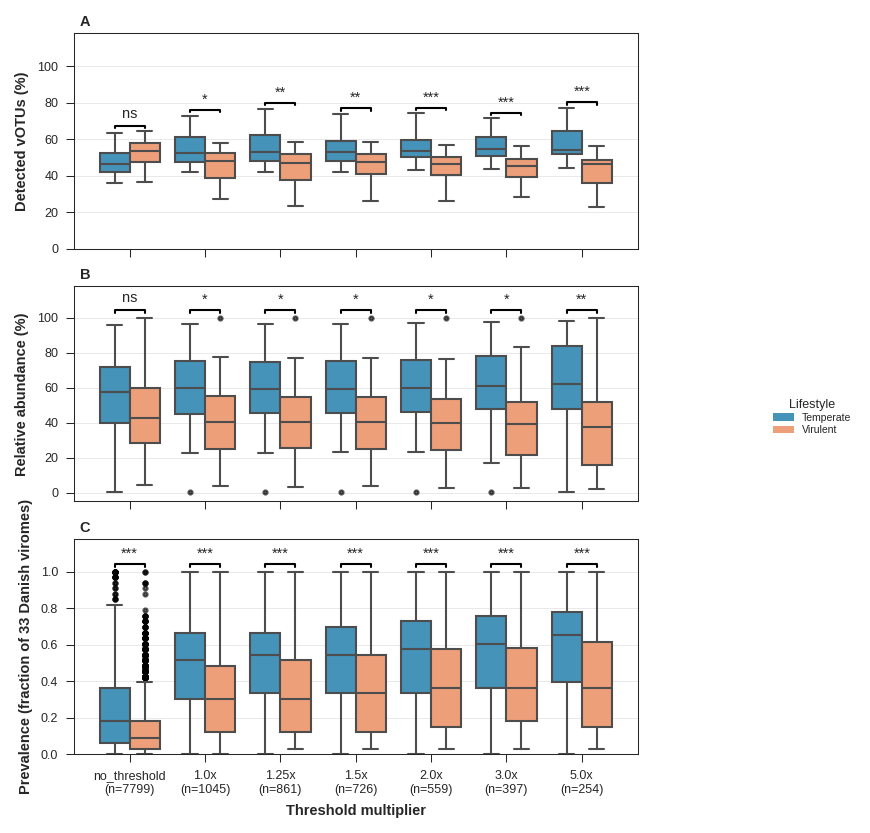

In [4]:
# Plot threshold sensitivity and significance
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

def add_lifestyle_significance_bars(axis, metric, frame, value_column):
    for position, threshold in enumerate(PLOT_THRESHOLD_KEYS):
        test_row = lifestyle_threshold_tests.loc[
            lifestyle_threshold_tests["threshold"].eq(threshold)
            & lifestyle_threshold_tests["metric"].eq(metric)
        ]
        if test_row.empty or pd.isna(test_row["p_value"].iloc[0]):
            continue

        ymax = frame.loc[
            frame["threshold"].eq(threshold),
            value_column,
        ].max()
        y = ymax * 1.025 if ymax > 0 else 0.01
        height = ymax * 0.018 if ymax > 0 else 0.01
        label = significance_label(test_row["p_value"].iloc[0])
        label_fontsize = 7
        label_offset = 2.5 if label == "ns" else 1.5

        axis.plot(
            [position - 0.2, position - 0.2, position + 0.2, position + 0.2],
            [y, y + height, y + height, y],
            lw=1,
            color="black",
        )
        axis.annotate(
            label,
            xy=(position, y + height),
            xytext=(0, label_offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
        )

threshold_labels = {
    threshold: (
        f"no_threshold\n(n={threshold_votu_counts[threshold]})"
        if threshold == "no_threshold"
        else f"{threshold}x\n(n={threshold_votu_counts[threshold]})"
    )
    for threshold in PLOT_THRESHOLD_KEYS
}
boxplot_flierprops = {
    "marker": "o",
    "markersize": 2,
    "markerfacecolor": "black",
    "markeredgecolor": "black",
    "alpha": 0.6,
}
lifestyle_figure_path = OUTPUT_DIR / "14_lifestyle_threshold_sensitivity.svg"

with sns.axes_style("ticks", {"axes.grid": True}), plt.rc_context(
    {
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "grid.linewidth": 0.25,
        "patch.linewidth": 0,
        "patch.edgecolor": "none",
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Liberation Sans"],
        "font.size": 5,
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "axes.titlepad": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.labelweight": "bold",
        "axes.titleweight": "bold",
        "legend.fontsize": 5,
        "legend.title_fontsize": 6,
        "legend.labelspacing": 0.2,
        "svg.fonttype": "none",
    }
):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5, 5.5), sharex=True)
    plot_specs = [
        (
            axes[0],
            detected_votu_proportion,
            "detected_votu_percent",
            "Detected vOTUs (%)",
            "detected_votu_proportion",
            (0, 118),
        ),
        (
            axes[1],
            relative_abundance,
            "relative_abundance_percent",
            "Relative abundance (%)",
            "relative_abundance",
            (-5, 118),
        ),
        (
            axes[2],
            prevalence_by_threshold,
            "prevalence",
            "Prevalence (fraction of 33 Danish viromes)",
            "prevalence",
            (0, 1.18),
        ),
    ]

    legend_handles = None
    legend_labels = None
    for panel_label, (axis, frame, value_column, ylabel, metric, ylim) in zip(
        "ABC",
        plot_specs,
    ):
        sns.boxplot(
            data=frame,
            x="threshold",
            y=value_column,
            hue="lifestyle",
            order=PLOT_THRESHOLD_KEYS,
            hue_order=LIFESTYLE_ORDER,
            palette=LIFESTYLE_PALETTE,
            flierprops=boxplot_flierprops,
            ax=axis,
        )
        add_lifestyle_significance_bars(axis, metric, frame, value_column)
        axis.set_ylabel(ylabel)
        axis.set_xlabel("")
        axis.set_ylim(*ylim)
        axis.text(
            0.01,
            1.02,
            panel_label,
            transform=axis.transAxes,
            ha="left",
            va="bottom",
            fontsize=7,
            fontweight="bold",
            clip_on=False,
        )

        handles, labels = axis.get_legend_handles_labels()
        if legend_handles is None:
            legend_handles = handles[:2]
            legend_labels = labels[:2]
        legend = axis.get_legend()
        if legend is not None:
            legend.remove()

    axes[-1].set_xlabel("Threshold multiplier")
    axes[-1].set_xticks(
        range(len(PLOT_THRESHOLD_KEYS)),
        [threshold_labels[threshold] for threshold in PLOT_THRESHOLD_KEYS],
    )
    fig.legend(
        legend_handles,
        legend_labels,
        title="Lifestyle",
        frameon=False,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0,
    )
    fig.tight_layout(rect=[0, 0, 0.86, 1])
    fig.savefig(lifestyle_figure_path, format="svg", bbox_inches="tight")
    fig.savefig(
        SUP_FIGS_TABLES_DIR / "SFigure1_activity_threshold_robustness.svg",
        format="svg",
        bbox_inches="tight",
    )

plt.show()
plt.close(fig)
